In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from catboost import CatBoostRegressor

# Load data
df = pd.read_csv('Raw_data.csv')

# Define features
feature_cols = [
    'Catalyst_type', 'time (min)', 'Surface area', 'Pore Volume',
    'Light_intensity (W)', 'Catalyst_loading (g/L)', 'HA (mg/L)',
    'solution_pH', 'Ci (mg/L)', 'Anions'
]
target_col = 'Efficiency (%)'

X = df[feature_cols]
y = df[target_col]

# One-hot encode
X_encoded = pd.get_dummies(X, columns=['Catalyst_type', 'Anions'], drop_first=False)

# Split 70/30 as paper did
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=313
)

# Train paper's model
model_paper = CatBoostRegressor(
    iterations=5000, learning_rate=0.5, l2_leaf_reg=5.0,
    model_size_reg=0.1, random_seed=313,
    verbose=False, early_stopping_rounds=100
)
model_paper.fit(X_train, y_train, eval_set=(X_test, y_test))

# Predictions for their method
y_test_pred = model_paper.predict(X_test)
test_r2 = r2_score(y_test, y_test_pred)

# Now train the honest model (leave-one-catalyst-out)
holdout = '2 wt% Pd-BFO'
train_mask = df['Catalyst_type'] != holdout
test_mask = df['Catalyst_type'] == holdout

X_train_real = X_encoded[train_mask]
X_test_real = X_encoded[test_mask]
y_train_real = y[train_mask]
y_test_real = y[test_mask]

model_honest = CatBoostRegressor(
    iterations=5000, learning_rate=0.5, l2_leaf_reg=5.0,
    model_size_reg=0.1, random_seed=313,
    verbose=False, early_stopping_rounds=100
)
model_honest.fit(X_train_real, y_train_real, eval_set=(X_test_real, y_test_real))

y_pred_real = model_honest.predict(X_test_real)
real_r2 = r2_score(y_test_real, y_pred_real)

print(f"Paper method R²: {test_r2:.4f}")
print(f"Honest method R²: {real_r2:.4f}")
print("Models ready for plotting.")

Paper method R²: 0.9973
Honest method R²: 0.6034
Models ready for plotting.


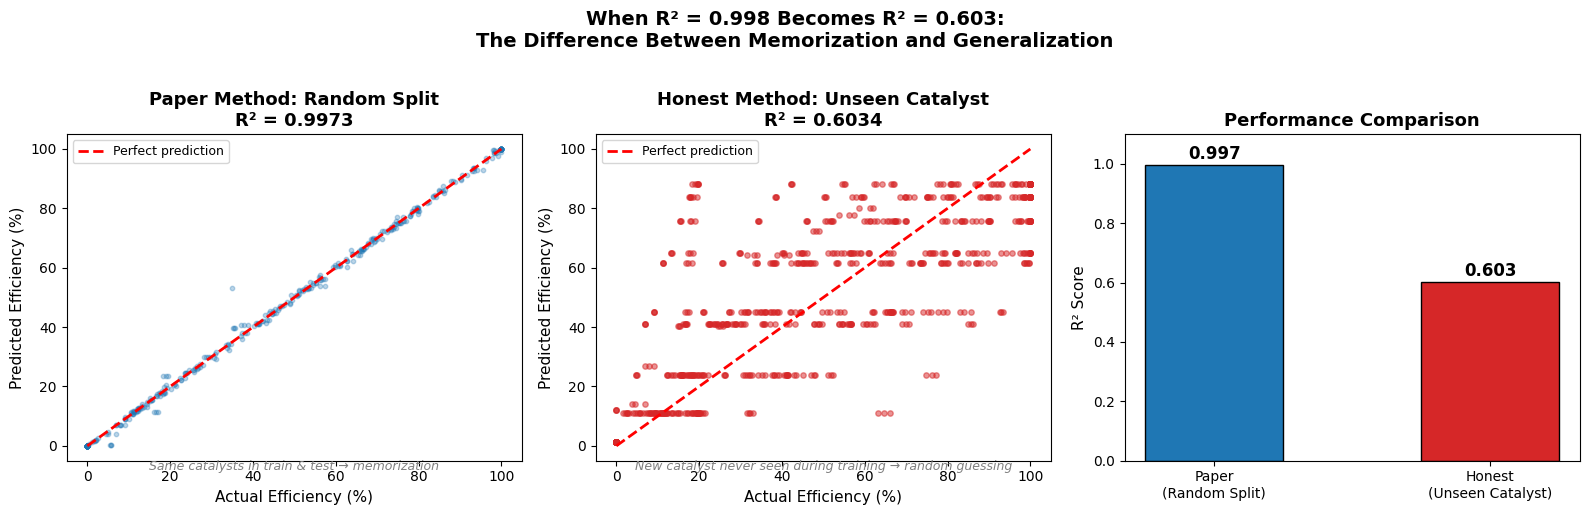

Figure 1 saved.


In [2]:
# FIGURE 1: Their Method vs Honest Validation

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Their method (random split)
axes[0].scatter(y_test, y_test_pred, alpha=0.3, s=10, color='#1f77b4')
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Efficiency (%)', fontsize=11)
axes[0].set_ylabel('Predicted Efficiency (%)', fontsize=11)
axes[0].set_title(f'Paper Method: Random Split\nR² = {test_r2:.4f}', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim(-5, 105)
axes[0].set_ylim(-5, 105)
axes[0].text(50, -8, 'Same catalysts in train & test → memorization',
             ha='center', fontsize=9, fontstyle='italic', color='gray')

# Panel 2: Honest method (unseen catalyst)
axes[1].scatter(y_test_real, y_pred_real, alpha=0.5, s=15, color='#d62728')
axes[1].plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Efficiency (%)', fontsize=11)
axes[1].set_ylabel('Predicted Efficiency (%)', fontsize=11)
axes[1].set_title(f'Honest Method: Unseen Catalyst\nR² = {real_r2:.4f}', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlim(-5, 105)
axes[1].set_ylim(-5, 105)
axes[1].text(50, -8, 'New catalyst never seen during training → random guessing',
             ha='center', fontsize=9, fontstyle='italic', color='gray')

# Panel 3: Bar chart comparison
methods = ['Paper\n(Random Split)', 'Honest\n(Unseen Catalyst)']
r2_values = [test_r2, real_r2]
colors_bar = ['#1f77b4', '#d62728']
bars = axes[2].bar(methods, r2_values, color=colors_bar, width=0.5, edgecolor='black')
axes[2].set_ylabel('R² Score', fontsize=11)
axes[2].set_title('Performance Comparison', fontsize=13, fontweight='bold')
axes[2].set_ylim(0, 1.1)
for bar, val in zip(bars, r2_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')
axes[2].axhline(y=0, color='black', linewidth=0.5)

plt.suptitle('When R² = 0.998 Becomes R² = 0.603:\nThe Difference Between Memorization and Generalization',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('their_method_vs_honest.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

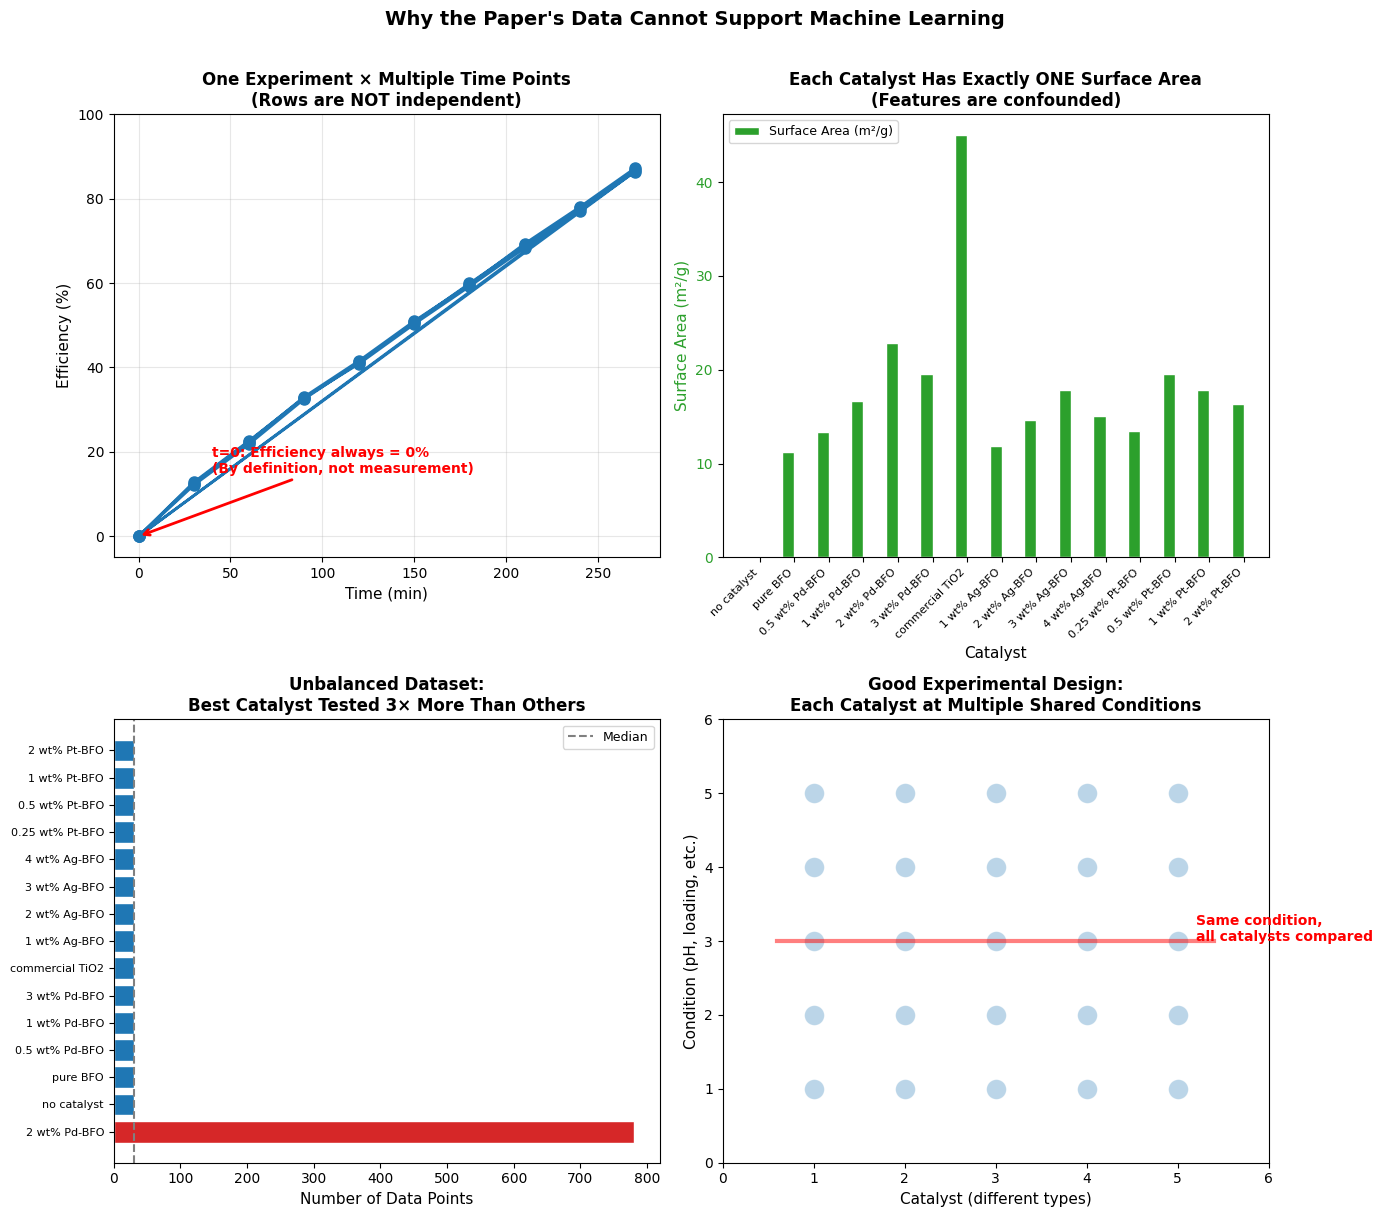

Figure 2 saved.


In [3]:
# FIGURE 2: The Three Data Problems

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Subplot 1: Data structure - time dependence
ax = axes[0, 0]
exp_data = df[
    (df['Catalyst_type'] == '0.25 wt% Pt-BFO') & 
    (df['Light_intensity (W)'] == 105) &
    (df['Catalyst_loading (g/L)'] == 1.0)
]
ax.plot(exp_data['time (min)'], exp_data['Efficiency (%)'], 'o-', color='#1f77b4', linewidth=2, markersize=8)
ax.set_xlabel('Time (min)', fontsize=11)
ax.set_ylabel('Efficiency (%)', fontsize=11)
ax.set_title('One Experiment × Multiple Time Points\n(Rows are NOT independent)', fontsize=12, fontweight='bold')
ax.set_ylim(-5, 100)
ax.grid(True, alpha=0.3)
ax.annotate('t=0: Efficiency always = 0%\n(By definition, not measurement)', 
            xy=(0, 0), xytext=(40, 15),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=10, color='red', fontweight='bold')

# Subplot 2: Confounded features
ax = axes[0, 1]
catalyst_props = df[['Catalyst_type', 'Surface area', 'Pore Volume']].drop_duplicates()
short_names = [name[:25] for name in catalyst_props['Catalyst_type']]
x = np.arange(len(catalyst_props))
width = 0.35
bars1 = ax.bar(x - width/2, catalyst_props['Surface area'], width, label='Surface Area (m²/g)', 
               color='#2ca02c', edgecolor='white')
ax.set_xlabel('Catalyst', fontsize=11)
ax.set_ylabel('Surface Area (m²/g)', fontsize=11, color='#2ca02c')
ax.tick_params(axis='y', labelcolor='#2ca02c')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
ax.set_title('Each Catalyst Has Exactly ONE Surface Area\n(Features are confounded)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')

# Subplot 3: Broken experimental design
ax = axes[1, 0]
cat_counts = df['Catalyst_type'].value_counts()
colors_doe = ['#d62728' if cat == '2 wt% Pd-BFO' else '#1f77b4' for cat in cat_counts.index]
short_idx = [name[:25] for name in cat_counts.index]
ax.barh(range(len(cat_counts)), cat_counts.values, color=colors_doe, edgecolor='white')
ax.set_yticks(range(len(cat_counts)))
ax.set_yticklabels(short_idx, fontsize=8)
ax.set_xlabel('Number of Data Points', fontsize=11)
ax.set_title('Unbalanced Dataset:\nBest Catalyst Tested 3× More Than Others', fontsize=12, fontweight='bold')
ax.axvline(x=cat_counts.median(), color='gray', linestyle='--', label='Median')
ax.legend(fontsize=9)

# Subplot 4: What a good design looks like
ax = axes[1, 1]
ax.set_xlim(0, 6)
ax.set_ylim(0, 6)
ax.set_xlabel('Catalyst (different types)', fontsize=11)
ax.set_ylabel('Condition (pH, loading, etc.)', fontsize=11)
ax.set_title('Good Experimental Design:\nEach Catalyst at Multiple Shared Conditions',
             fontsize=12, fontweight='bold')
np.random.seed(42)
for i in range(5):
    for j in range(5):
        ax.scatter(i+1, j+1, s=200, alpha=0.3, color='#1f77b4', edgecolors='white', linewidth=0.5)
ax.axhline(y=3, xmin=0.1, xmax=0.9, color='red', linewidth=3, alpha=0.5)
ax.text(5.2, 3, 'Same condition,\nall catalysts compared', fontsize=10, color='red', fontweight='bold')

plt.suptitle('Why the Paper\'s Data Cannot Support Machine Learning',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('data_problems.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

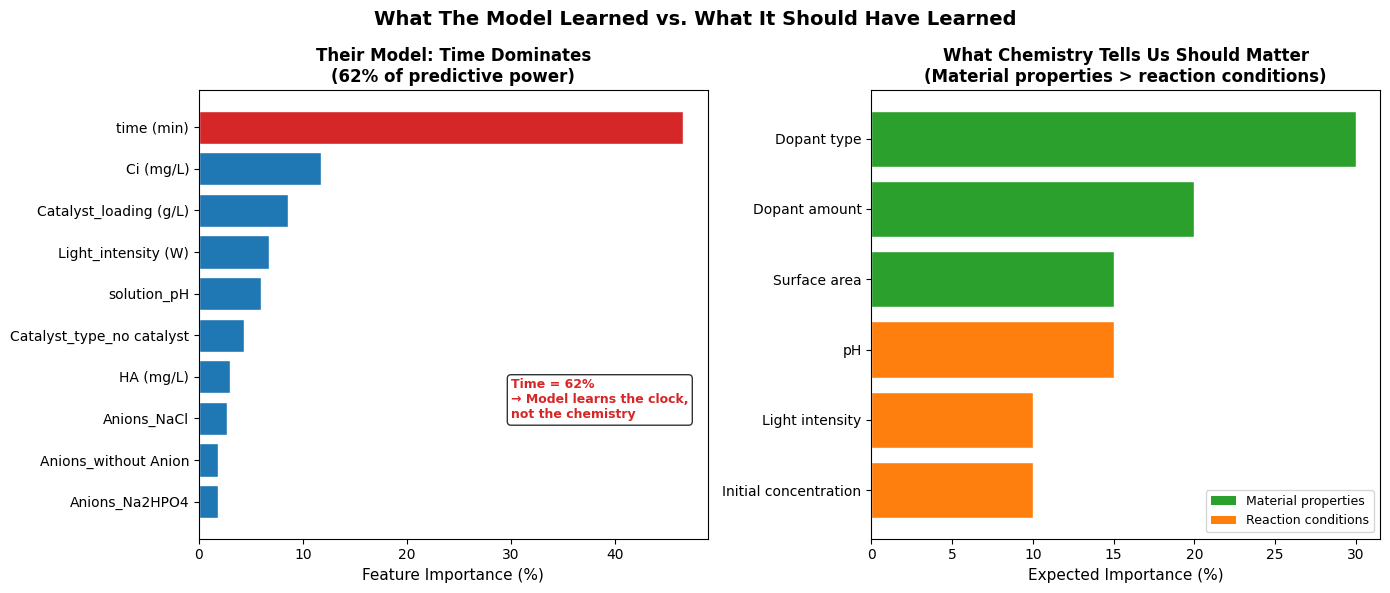

Figure 3 saved.


In [4]:
# FIGURE 3: Feature Importance - What The Model Actually Learned

# Get feature importance from the paper's model
importance_full = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': model_paper.feature_importances_
}).sort_values('importance', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Their model feature importance
ax = axes[0]
colors_left = ['#d62728' if 'time' in f.lower() else '#1f77b4' for f in importance_full['feature'].values[::-1]]
bars = ax.barh(importance_full['feature'].values[::-1], 
               importance_full['importance'].values[::-1],
               color=colors_left, edgecolor='white')
ax.set_xlabel('Feature Importance (%)', fontsize=11)
ax.set_title('Their Model: Time Dominates\n(62% of predictive power)', fontsize=12, fontweight='bold')
ax.text(30, 2, 'Time = 62%\n→ Model learns the clock,\nnot the chemistry', 
        fontsize=9, color='#d62728', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# What the model should have learned (conceptual)
ax = axes[1]
conceptual_features = ['Dopant type', 'Dopant amount', 'Surface area', 
                       'pH', 'Light intensity', 'Initial concentration']
conceptual_importance = [30, 20, 15, 15, 10, 10]
colors_right = ['#2ca02c', '#2ca02c', '#2ca02c', '#ff7f0e', '#ff7f0e', '#ff7f0e']
bars = ax.barh(conceptual_features[::-1], conceptual_importance[::-1], 
               color=colors_right[::-1], edgecolor='white')
ax.set_xlabel('Expected Importance (%)', fontsize=11)
ax.set_title('What Chemistry Tells Us Should Matter\n(Material properties > reaction conditions)',
             fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ca02c', label='Material properties'),
                   Patch(facecolor='#ff7f0e', label='Reaction conditions')]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.suptitle('What The Model Learned vs. What It Should Have Learned',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_reality.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

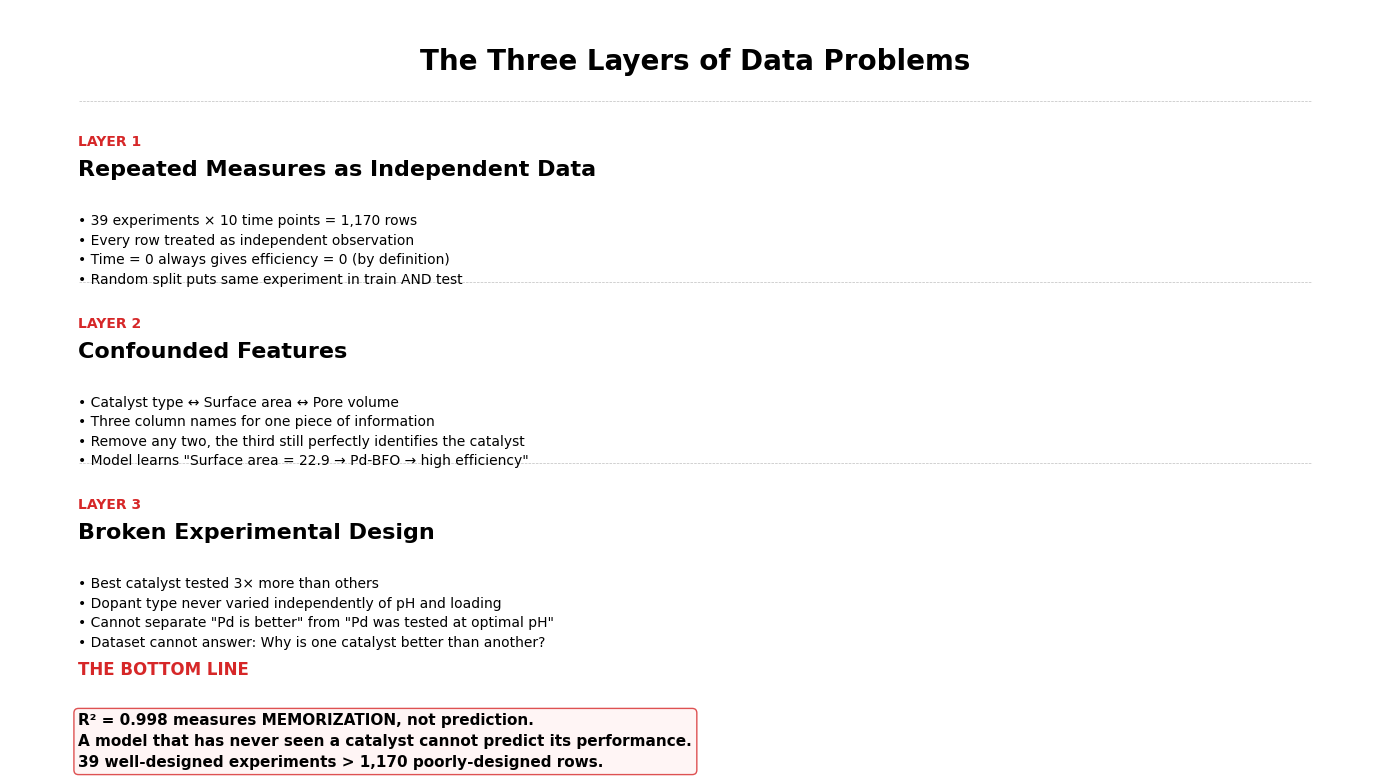

Figure 4 saved.


In [5]:
# FIGURE 4: Summary Infographic

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Title
ax.text(5, 9.5, 'The Three Layers of Data Problems', fontsize=20, fontweight='bold', 
        ha='center', va='top')

# Layer 1
ax.text(0.5, 8.2, 'LAYER 1', fontsize=10, fontweight='bold', color='#d62728')
ax.text(0.5, 7.8, 'Repeated Measures as Independent Data', fontsize=16, fontweight='bold')
ax.text(0.5, 7.3, '• 39 experiments × 10 time points = 1,170 rows\n• Every row treated as independent observation\n• Time = 0 always gives efficiency = 0 (by definition)\n• Random split puts same experiment in train AND test', 
        fontsize=10, va='top', linespacing=1.5)

# Layer 2
ax.text(0.5, 5.8, 'LAYER 2', fontsize=10, fontweight='bold', color='#d62728')
ax.text(0.5, 5.4, 'Confounded Features', fontsize=16, fontweight='bold')
ax.text(0.5, 4.9, '• Catalyst type ↔ Surface area ↔ Pore volume\n• Three column names for one piece of information\n• Remove any two, the third still perfectly identifies the catalyst\n• Model learns "Surface area = 22.9 → Pd-BFO → high efficiency"', 
        fontsize=10, va='top', linespacing=1.5)

# Layer 3
ax.text(0.5, 3.4, 'LAYER 3', fontsize=10, fontweight='bold', color='#d62728')
ax.text(0.5, 3.0, 'Broken Experimental Design', fontsize=16, fontweight='bold')
ax.text(0.5, 2.5, '• Best catalyst tested 3× more than others\n• Dopant type never varied independently of pH and loading\n• Cannot separate "Pd is better" from "Pd was tested at optimal pH"\n• Dataset cannot answer: Why is one catalyst better than another?', 
        fontsize=10, va='top', linespacing=1.5)

# The Bottom Line
ax.text(0.5, 1.2, 'THE BOTTOM LINE', fontsize=12, fontweight='bold', color='#d62728')
ax.text(0.5, 0.7, 'R² = 0.998 measures MEMORIZATION, not prediction.\nA model that has never seen a catalyst cannot predict its performance.\n39 well-designed experiments > 1,170 poorly-designed rows.',
        fontsize=11, va='top', linespacing=1.5, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#fff3f3', alpha=0.8, edgecolor='#d62728'))

# Divider lines
for y_pos in [8.8, 6.4, 4.0]:
    ax.axhline(y=y_pos, xmin=0.05, xmax=0.95, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('summary_infographic.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

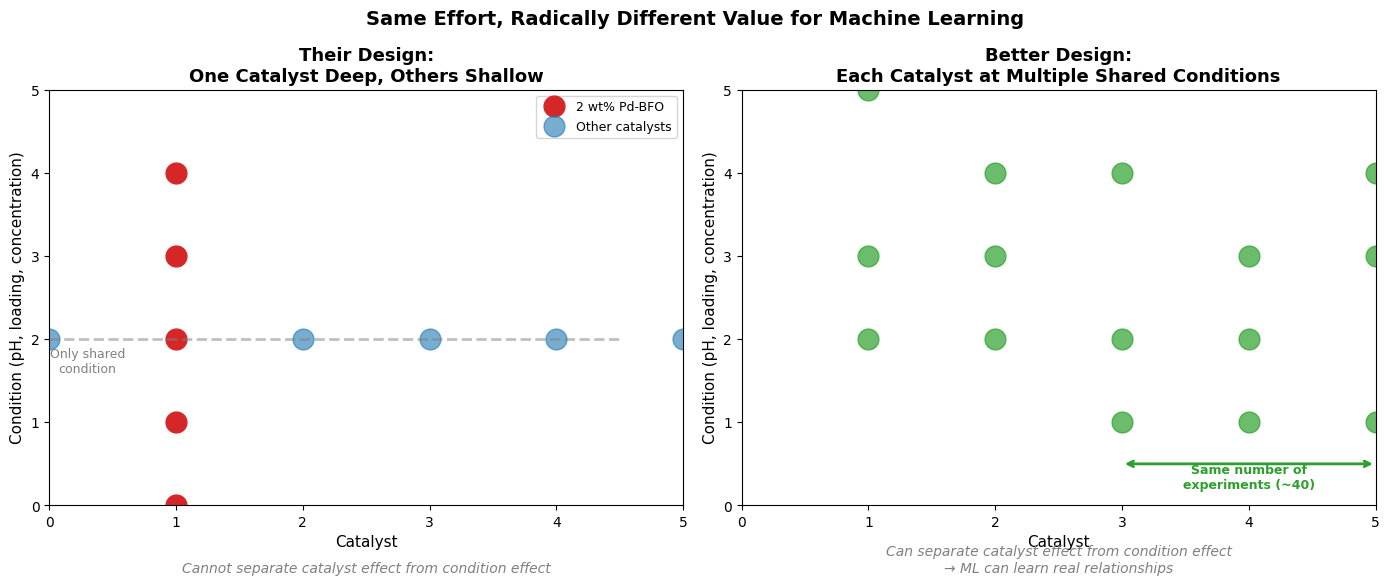

Figure 5 saved.


In [6]:
# FIGURE 5: Good vs Bad Experimental Design

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bad design (what they did)
ax = axes[0]
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_xlabel('Catalyst', fontsize=11)
ax.set_ylabel('Condition (pH, loading, concentration)', fontsize=11)
ax.set_title('Their Design:\nOne Catalyst Deep, Others Shallow', fontsize=13, fontweight='bold')

# Pd-BFO: tested at many conditions
ax.plot([1]*5, range(5), 'o', color='#d62728', markersize=15, label='2 wt% Pd-BFO')
# Other catalysts: tested at one condition
for i in range(2, 6):
    ax.plot(i, 2, 'o', color='#1f77b4', markersize=15, alpha=0.6)
ax.plot(0, 2, 'o', color='#1f77b4', markersize=15, alpha=0.6, label='Other catalysts')

ax.axhline(y=2, xmin=0, xmax=0.9, color='gray', linestyle='--', alpha=0.5, linewidth=2)
ax.text(0.3, 1.6, 'Only shared\ncondition', fontsize=9, ha='center', color='gray')
ax.legend(fontsize=9, loc='upper right')
ax.text(2.5, -0.8, 'Cannot separate catalyst effect from condition effect',
        ha='center', fontsize=10, fontstyle='italic', color='gray')

# Good design
ax = axes[1]
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_xlabel('Catalyst', fontsize=11)
ax.set_ylabel('Condition (pH, loading, concentration)', fontsize=11)
ax.set_title('Better Design:\nEach Catalyst at Multiple Shared Conditions', fontsize=13, fontweight='bold')

np.random.seed(42)
for i in range(5):
    conditions = np.random.choice(5, 3, replace=False)
    for j in conditions:
        ax.plot(i+1, j+1, 'o', color='#2ca02c', markersize=15, alpha=0.7)

ax.text(2.5, -0.8, 'Can separate catalyst effect from condition effect\n→ ML can learn real relationships',
        ha='center', fontsize=10, fontstyle='italic', color='gray')

ax.annotate('', xy=(3, 0.5), xytext=(5, 0.5),
            arrowprops=dict(arrowstyle='<->', color='#2ca02c', lw=2))
ax.text(4, 0.2, 'Same number of\nexperiments (~40)', ha='center', fontsize=9, 
        color='#2ca02c', fontweight='bold')

plt.suptitle('Same Effort, Radically Different Value for Machine Learning',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('doe_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("Figure 5 saved.")